## Dynamic GEP Hierarchy Tree Builder

This notebook builds a hierarchical tree of Gene Expression Programs (GEPs) and **dynamically determines** when to stop based on cell type differentiation.

**Stopping criterion**: The tree stops growing when a specified fraction (`MIN_DIFFERENTIATED_FRACTION`) of GEPs in the current K row have at least `MIN_CELLTYPE_GAP` difference between their top 2 cell types.

For example, with `MIN_DIFFERENTIATED_FRACTION=0.75` and `MIN_CELLTYPE_GAP=0.20`, the algorithm stops when 75% of GEPs have ≥20% gap between their top 2 cell types.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx as nx
from collections import Counter

In [2]:
# ============================================================================
# STOPPING CRITERION PARAMETERS
# ============================================================================
MIN_CELLTYPE_GAP = 0.6  # Minimum gap between top 2 cell types for a GEP to be "differentiated"
MIN_DIFFERENTIATED_FRACTION = 0.75  # Fraction of GEPs that must be differentiated to stop (e.g., 0.75 = 75%)

# ============================================================================
# DATA PATHS
# ============================================================================
GSEA_FOLDER = "gsea_results_S1_C8merged"
FILE_GLOB = "*.csv"
USAGE_FOLDER = "cnmf_results_S1_k3-30"
METADATA_CSV = "data/anal_cancer_n21_meta.csv" 
CELLTYPE_COL = "cluster_annot3"  

# Which enrichment score to use as the program->pathway embedding
SCORE_COL = "NES"

# Similarity settings: "pearson" or "cosine" or "spearman"
SIMILARITY = "spearman"

# ============================================================================
# HIERARCHY TREE PARAMETERS
# ============================================================================
HI_THRESH = 0.90      # if best similarity >= HI_THRESH -> single green edge
MAX_PARENTS = 3       # if best similarity < HI_THRESH -> keep top N parents
MIN_SIM = None        # optional: drop edges below this (only applies in multi-parent case)

# ============================================================================
# CELL TYPE ANNOTATION PARAMETERS
# ============================================================================
TOP_CELLS_FRACTION = 0.10  # Top fraction of cells by GEP usage
TOP_N_CELLTYPES = 3        # Number of top cell types to consider

# ============================================================================
# OPTIONAL: Starting K (None = start from minimum available K)
# ============================================================================
K_START = None  # Set to e.g. 5 to start from K=5

# ============================================================================
# OUTPUT FILES
# ============================================================================
OUT_EDGES_CSV = "dynamic_hierarch_tree_results/gep_tree_edges_dynamic.csv"
OUT_CELLTYPE_CSV = "dynamic_hierarch_tree_results/gep_celltype_annotations_dynamic.csv"

### 1. Load all GSEA results

In [3]:
def load_gsea_folder(folder: str, file_glob="*.csv") -> pd.DataFrame:
    folder = Path(folder)
    files = sorted(folder.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files matched {file_glob} in {folder}")

    dfs = []
    for fp in files:
        if fp.suffix.lower() in [".csv", ".tsv", ".txt"]:
            df = pd.read_csv(fp)
        elif fp.suffix.lower() in [".xlsx", ".xls"]:
            df = pd.read_excel(fp)
        else:
            raise ValueError(f"Unsupported file type: {fp}")

        df["__source_file__"] = fp.name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    return out

gsea_all = load_gsea_folder(GSEA_FOLDER, FILE_GLOB)
print("Loaded rows:", len(gsea_all))
print("Columns:", list(gsea_all.columns))

# Drop 'Name' column if exists
if 'Name' in gsea_all.columns:
    gsea_all = gsea_all.drop(columns=['Name'])

print("\nAvailable K values:", sorted(gsea_all['K'].unique()))
gsea_all.head()

Loaded rows: 567336
Columns: ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr', 'Name', 'ES', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'spectra_file', '__source_file__']

Available K values: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


,K,GEP,pathway,NES,pval,fdr,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file,__source_file__
0,10,1,CTX_BIG_GROUPS_BRAIN_IMMUNE,-3.486940,0.0,0.0,-0.774985,0.0,73/97,11.14%,ARHGEF1;AKNA;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
1,10,1,B_T,-3.277324,0.0,0.0,-0.743859,0.0,106/123,21.24%,ARHGEF1;LAPTM5;IL2RG;CORO1A;ACAP1;ARHGAP15;TMC...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
2,10,1,LYMPHOID,-3.183676,0.0,0.0,-0.658074,0.0,158/238,21.28%,ARHGEF1;IL2RG;CORO1A;TMC8;RAC2;LTB;SEPTIN1;IL3...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
3,10,1,CTX_BRAIN_EFFECTOR_T,-3.119706,0.0,0.0,-0.678304,0.0,77/105,21.24%,AKNA;IL2RG;CORO1A;ACAP1;ITGAL;ADGRE5;RAC2;SEPT...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
4,10,1,MUSCLE_MYELOID,-3.024891,0.0,0.0,-0.617550,0.0,137/201,26.50%,CYBA;CTSS;LAPTM5;CD74;CORO1A;CD53;SOD2;KYNU;TM...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv


### 2. Build NES matrices for all K values

In [4]:
def build_k_to_matrix(df: pd.DataFrame, score_col="NES") -> dict[int, pd.DataFrame]:
    df = df.copy()
    df["program_id"] = df.apply(lambda r: f"K{int(r['K'])}_GEP{int(r['GEP'])}", axis=1)

    k_to_mat = {}
    for k, sub in df.groupby("K"):
        mat = sub.pivot_table(
            index="program_id",
            columns="pathway",
            values=score_col,
            aggfunc="max"
        )
        mat = mat.fillna(0.0)
        k_to_mat[int(k)] = mat

    return k_to_mat

k_to_mat = build_k_to_matrix(gsea_all, score_col=SCORE_COL)
all_available_ks = sorted(k_to_mat.keys())

print("Built matrices for Ks:", all_available_ks)
some_k = all_available_ks[0]
print(f"Example K={some_k} shape:", k_to_mat[some_k].shape)

Built matrices for Ks: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Example K=3 shape: (3, 614)


### 3. Load metadata and build cell type annotation functions

In [5]:
print(f"Loading metadata from: {METADATA_CSV}")
metadata = pd.read_csv(METADATA_CSV, index_col=0)
cell_to_type = metadata[CELLTYPE_COL]
print(f"Loaded {len(cell_to_type)} cells with {cell_to_type.nunique()} unique cell types")

Loading metadata from: data/anal_cancer_n21_meta.csv
Loaded 304634 cells with 19 unique cell types


/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_69836/3487463014.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(METADATA_CSV, index_col=0)


In [6]:
def get_top_celltypes_for_gep(
    usage_series: pd.Series,
    cell_to_type: pd.Series,
    top_fraction: float = 0.10,
    top_n: int = 3,
    min_gap: float = 0.20
) -> tuple[list[tuple[str, float]], float]:
    common_cells = usage_series.index.intersection(cell_to_type.index)
    if len(common_cells) == 0:
        return [("Unknown", 1.0)], 1.0
    
    usage_aligned = usage_series.loc[common_cells]
    types_aligned = cell_to_type.loc[common_cells]
    
    n_top = max(1, int(len(usage_aligned) * top_fraction))
    top_cells = usage_aligned.nlargest(n_top).index
    top_cell_types = types_aligned.loc[top_cells]
    
    type_counts = Counter(top_cell_types)
    total = sum(type_counts.values()) or 1
    top_types = [(ct, count / total) for ct, count in type_counts.most_common(top_n)]
    
    if len(top_types) >= 2:
        gap = top_types[0][1] - top_types[1][1]
    else:
        gap = 1.0
    
    if len(top_types) >= 2 and gap < min_gap:
        mixed_label = "Mixed: " + "/".join([t[0] for t in top_types])
        formatted_types = [(mixed_label, sum(t[1] for t in top_types))] + top_types
    else:
        formatted_types = top_types
    
    return formatted_types, gap


def format_celltype_annotation(top_types: list[tuple[str, float]]) -> str:
    return ", ".join([f"{ct} ({prop*100:.0f}%)" for ct, prop in top_types])

In [7]:
def _detect_gep_column_indexing(cols) -> str:
    col_ints = []
    for c in cols:
        try:
            col_ints.append(int(c))
        except Exception:
            pass
    if not col_ints:
        return "unknown"
    mn = min(col_ints)
    if mn == 0:
        return "zero"
    if mn == 1:
        return "one"
    return "unknown"

In [8]:
def annotate_geps_for_k(
    usage_folder: str,
    cell_to_type: pd.Series,
    k: int,
    top_fraction: float = 0.10,
    top_n: int = 3,
    min_gap: float = 0.20
) -> pd.DataFrame:
    results = []
    folder = Path(usage_folder)
    pattern = f"*.usages.k_{k}.dt_0_01.consensus.txt"
    files = list(folder.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No usage file found for K={k} in {usage_folder}")
    usage_df = pd.read_csv(files[0], sep="\t", index_col=0)
    indexing = _detect_gep_column_indexing(usage_df.columns)

    for col in usage_df.columns:
        if indexing == "zero":
            try:
                gep_num = int(col) + 1
            except Exception:
                gep_num = list(usage_df.columns).index(col) + 1
        elif indexing == "one":
            try:
                gep_num = int(col)
            except Exception:
                gep_num = list(usage_df.columns).index(col) + 1
        else:
            gep_num = list(usage_df.columns).index(col) + 1

        program_id = f"K{k}_GEP{gep_num}"
        top_types, gap = get_top_celltypes_for_gep(
            usage_df[col], cell_to_type,
            top_fraction=top_fraction, top_n=top_n, min_gap=min_gap
        )
        results.append({
            "K": k,
            "GEP": f"GEP{gep_num}",
            "program_id": program_id,
            "gep_col": str(col),
            "top1_celltype": top_types[0][0] if top_types else "Unknown",
            "top_celltypes": format_celltype_annotation(top_types),
            "top_celltypes_list": top_types,
            "celltype_gap": gap,
        })
    return pd.DataFrame(results)

### 4. Dynamic K determination based on cell type differentiation

The algorithm iterates through K values and stops when the specified fraction of GEPs meet the cell type differentiation criterion.

In [9]:
def find_optimal_k_max(
    usage_folder: str,
    cell_to_type: pd.Series,
    available_ks: list[int],
    min_celltype_gap: float = 0.20,
    min_differentiated_fraction: float = 1.0,
    top_fraction: float = 0.10,
    top_n: int = 3,
    k_start: int = None
) -> tuple[int, pd.DataFrame]:
    """
    Find the optimal K where the stopping criterion is met.
    
    Parameters
    ----------
    usage_folder : str
        Path to folder containing usage files
    cell_to_type : pd.Series
        Mapping from cell IDs to cell types
    available_ks : list[int]
        List of available K values
    min_celltype_gap : float
        Minimum gap between top 2 cell types for a GEP to be "differentiated"
    min_differentiated_fraction : float
        Fraction of GEPs that must be differentiated to stop (e.g., 0.75 = 75%)
    top_fraction : float
        Fraction of top cells to use for annotation
    top_n : int
        Number of top cell types to consider
    k_start : int, optional
        Starting K value (default: minimum available K)
    
    Returns
    -------
    tuple[int, pd.DataFrame]
        Optimal K and DataFrame with all annotations up to that K
    """
    k_begin = k_start if k_start else min(available_ks)
    all_annotations = []
    optimal_k = None
    
    print(f"\n{'='*70}")
    print(f"Finding optimal K with:")
    print(f"  MIN_CELLTYPE_GAP = {min_celltype_gap*100:.0f}%")
    print(f"  MIN_DIFFERENTIATED_FRACTION = {min_differentiated_fraction*100:.0f}%")
    print(f"{'='*70}\n")
    
    for k in sorted(available_ks):
        if k < k_begin:
            continue
        print(f"\nAnalyzing K={k}...")
        try:
            k_annotations = annotate_geps_for_k(
                usage_folder, cell_to_type, k,
                top_fraction=top_fraction, top_n=top_n, min_gap=min_celltype_gap
            )
            all_annotations.append(k_annotations)
            
            gaps = k_annotations['celltype_gap'].values
            n_geps = len(k_annotations)
            n_differentiated = (gaps >= min_celltype_gap).sum()
            differentiated_fraction = n_differentiated / n_geps if n_geps > 0 else 0
            min_gap_at_k = gaps.min()
            
            print(f"  GEPs at K={k}: {n_geps}")
            print(f"  Differentiated GEPs: {n_differentiated}/{n_geps} ({differentiated_fraction*100:.1f}%)")
            print(f"  Min gap: {min_gap_at_k*100:.1f}%")
            
            # Show GEPs that are NOT differentiated
            below_thresh = k_annotations[k_annotations['celltype_gap'] < min_celltype_gap]
            if len(below_thresh) > 0:
                print(f"  GEPs with ambiguous cell types (gap < {min_celltype_gap*100:.0f}%):")
                for _, row in below_thresh.iterrows():
                    print(f"      {row['program_id']}: gap={row['celltype_gap']*100:.1f}% - {row['top_celltypes']}")
            
            # Check stopping criterion
            if differentiated_fraction >= min_differentiated_fraction:
                print(f"\n*** STOPPING CRITERION MET at K={k}! ***")
                print(f"    {n_differentiated}/{n_geps} ({differentiated_fraction*100:.1f}%) GEPs have >= {min_celltype_gap*100:.0f}% gap")
                print(f"    Required: >= {min_differentiated_fraction*100:.0f}%")
                optimal_k = k
                break
            else:
                needed = int(np.ceil(min_differentiated_fraction * n_geps))
                print(f"  Criterion not met (need {needed}/{n_geps} differentiated), continuing...")
        except FileNotFoundError as e:
            print(f"  Skipping K={k}: {e}")
            continue
    
    if optimal_k is None:
        optimal_k = max([df['K'].iloc[0] for df in all_annotations]) if all_annotations else k_begin
        print(f"\nWarning: Stopping criterion never fully met. Using K={optimal_k}")
    
    combined_annotations = pd.concat(all_annotations, ignore_index=True) if all_annotations else pd.DataFrame()
    return optimal_k, combined_annotations


optimal_k_max, gep_annotations = find_optimal_k_max(
    USAGE_FOLDER, cell_to_type, all_available_ks,
    min_celltype_gap=MIN_CELLTYPE_GAP,
    min_differentiated_fraction=MIN_DIFFERENTIATED_FRACTION,
    top_fraction=TOP_CELLS_FRACTION,
    top_n=TOP_N_CELLTYPES,
    k_start=K_START
)

print(f"\n{'='*70}")
print(f"RESULT: Optimal K_MAX = {optimal_k_max}")
print(f"{'='*70}")


Finding optimal K with:
  MIN_CELLTYPE_GAP = 60%
  MIN_DIFFERENTIATED_FRACTION = 75%


Analyzing K=3...
  GEPs at K=3: 3
  Differentiated GEPs: 1/3 (33.3%)
  Min gap: 9.1%
  GEPs with ambiguous cell types (gap < 60%):
      K3_GEP1: gap=33.0% - Mixed: Tumor/Epithelials/Fibroblasts/Stromal/Endothelials (100%), Tumor/Epithelials (63%), Fibroblasts/Stromal (30%), Endothelials (6%)
      K3_GEP2: gap=9.1% - Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (51%), Bcells_CD19 (23%), CD4+Tcells (14%), CD8+Tcells (14%)
  Criterion not met (need 3/3 differentiated), continuing...

Analyzing K=4...
  GEPs at K=4: 4
  Differentiated GEPs: 2/4 (50.0%)
  Min gap: 9.3%
  GEPs with ambiguous cell types (gap < 60%):
      K4_GEP1: gap=9.3% - Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (52%), Bcells_CD19 (24%), CD4+Tcells (14%), CD8+Tcells (14%)
      K4_GEP4: gap=55.1% - Mixed: Fibroblasts/Stromal/Endothelials/Tumor/Epithelials (97%), Fibroblasts/Stromal (73%), Endothelials (18%), Tumor/Epithelials (6%)
  Crite

In [10]:
k_start_display = K_START if K_START else min(all_available_ks)
print(f"\nCell type annotations for K={k_start_display} to K={optimal_k_max}:")
print(f"Total GEPs annotated: {len(gep_annotations)}\n")

for k in sorted(gep_annotations['K'].unique()):
    k_data = gep_annotations[gep_annotations['K'] == k]
    n_diff = (k_data['celltype_gap'] >= MIN_CELLTYPE_GAP).sum()
    print(f"\nK={k} ({len(k_data)} GEPs, {n_diff} differentiated):")
    for _, row in k_data.iterrows():
        gap_indicator = "Y" if row['celltype_gap'] >= MIN_CELLTYPE_GAP else "N"
        print(f"  [{gap_indicator}] {row['program_id']}: {row['top_celltypes'][:80]}... (gap: {row['celltype_gap']*100:.1f}%)")


Cell type annotations for K=3 to K=30:
Total GEPs annotated: 462


K=3 (3 GEPs, 1 differentiated):
  [N] K3_GEP1: Mixed: Tumor/Epithelials/Fibroblasts/Stromal/Endothelials (100%), Tumor/Epitheli... (gap: 33.0%)
  [N] K3_GEP2: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (51%), Bcells_CD19 (23%), CD4+Tcells (1... (gap: 9.1%)
  [Y] K3_GEP3: Tumor/Epithelials (100%), Endothelials (0%), Fibroblasts/Stromal (0%)... (gap: 99.6%)

K=4 (4 GEPs, 2 differentiated):
  [N] K4_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (52%), Bcells_CD19 (24%), CD4+Tcells (1... (gap: 9.3%)
  [Y] K4_GEP2: Tumor/Epithelials (98%), Fibroblasts/Stromal (1%), Endothelials (0%)... (gap: 97.3%)
  [Y] K4_GEP3: Tumor/Epithelials (100%), Fibroblasts/Stromal (0%), Endothelials (0%)... (gap: 99.4%)
  [N] K4_GEP4: Mixed: Fibroblasts/Stromal/Endothelials/Tumor/Epithelials (97%), Fibroblasts/Str... (gap: 55.1%)

K=5 (5 GEPs, 2 differentiated):
  [N] K5_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (64%), Bcells_CD19 (23%), CD4+

### 5. Build the hierarchical tree with the optimal K range

In [11]:
k_start_val = K_START if K_START is not None else min(all_available_ks)
k_chain = [k for k in range(k_start_val, optimal_k_max + 1) if k in k_to_mat]
print(f"Using K chain: {k_chain}")
print(f"(Determined dynamically with MIN_CELLTYPE_GAP={MIN_CELLTYPE_GAP*100:.0f}%, MIN_DIFFERENTIATED_FRACTION={MIN_DIFFERENTIATED_FRACTION*100:.0f}%)")

Using K chain: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
(Determined dynamically with MIN_CELLTYPE_GAP=60%, MIN_DIFFERENTIATED_FRACTION=75%)


In [12]:
def cosine_similarity_matrix(B, A, eps=1e-12):
    A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return B_norm @ A_norm.T

def pearson_similarity_matrix(B, A, eps=1e-12):
    A0 = A - A.mean(axis=1, keepdims=True)
    B0 = B - B.mean(axis=1, keepdims=True)
    A_den = np.linalg.norm(A0, axis=1, keepdims=True) + eps
    B_den = np.linalg.norm(B0, axis=1, keepdims=True) + eps
    return (B0 / B_den) @ (A0 / A_den).T

def _rank_rows_dense(X):
    return pd.DataFrame(X).rank(axis=1, method="dense").to_numpy(dtype=float)

def spearman_similarity_matrix(B, A):
    return pearson_similarity_matrix(_rank_rows_dense(B), _rank_rows_dense(A))

def similarity_matrix(df_child, df_parent, method="pearson"):
    common = df_child.columns.intersection(df_parent.columns)
    if len(common) == 0:
        raise ValueError("No overlapping pathway columns")
    B = df_child[common].to_numpy(dtype=float)
    A = df_parent[common].to_numpy(dtype=float)
    method = method.lower().strip()
    if method == "cosine":
        C = cosine_similarity_matrix(B, A)
    elif method == "pearson":
        C = pearson_similarity_matrix(B, A)
    elif method == "spearman":
        C = spearman_similarity_matrix(B, A)
    else:
        raise ValueError("method must be 'pearson', 'cosine', or 'spearman'")
    return pd.DataFrame(C, index=df_child.index, columns=df_parent.index)

print("Similarity method:", SIMILARITY)

Similarity method: spearman


In [13]:
def build_tree_edges_multi(
    k_to_mat, k_chain, sim_method="pearson", hi_thresh=0.90,
    max_parents=3, min_sim=None,
    low_rank_colors=("purple", "red", "pink"), hi_color="green"
):
    edges = []
    for k in k_chain[:-1]:
        if (k not in k_to_mat) or (k + 1 not in k_to_mat):
            continue
        parent = k_to_mat[k]
        child = k_to_mat[k + 1]
        sim = similarity_matrix(child, parent, method=sim_method)
        for child_id, row in sim.iterrows():
            row_sorted = row.sort_values(ascending=False)
            best_parent = row_sorted.index[0]
            best_sim = float(row_sorted.iloc[0])
            if best_sim >= hi_thresh:
                edges.append({
                    "parent_k": k, "child_k": k + 1,
                    "parent_id": best_parent, "child_id": child_id,
                    "similarity": best_sim, "rank": 1,
                    "color": hi_color, "mode": "high"
                })
            else:
                top = row_sorted.head(max_parents)
                if min_sim is not None:
                    top = top[top >= float(min_sim)]
                    if top.empty:
                        top = row_sorted.head(1)
                for rnk, (pid, sval) in enumerate(top.items(), start=1):
                    color = low_rank_colors[rnk - 1] if rnk <= len(low_rank_colors) else low_rank_colors[-1]
                    edges.append({
                        "parent_k": k, "child_k": k + 1,
                        "parent_id": pid, "child_id": child_id,
                        "similarity": float(sval), "rank": rnk,
                        "color": color, "mode": "low"
                    })
    return pd.DataFrame(edges)

edges_df = build_tree_edges_multi(
    k_to_mat=k_to_mat, k_chain=k_chain, sim_method=SIMILARITY,
    hi_thresh=HI_THRESH, max_parents=MAX_PARENTS, min_sim=MIN_SIM
)
print(f"Edges: {len(edges_df)}")
edges_df.head(10)

Edges: 849


,parent_k,child_k,parent_id,child_id,similarity,rank,color,mode
0,3,4,K3_GEP2,K4_GEP1,0.995658,1,green,high
1,3,4,K3_GEP1,K4_GEP2,0.664541,1,purple,low
2,3,4,K3_GEP3,K4_GEP2,0.307791,2,red,low
3,3,4,K3_GEP2,K4_GEP2,-0.710903,3,pink,low
4,3,4,K3_GEP3,K4_GEP3,0.980244,1,green,high
5,3,4,K3_GEP1,K4_GEP4,0.593629,1,purple,low
6,3,4,K3_GEP3,K4_GEP4,-0.063749,2,red,low
7,3,4,K3_GEP2,K4_GEP4,-0.278402,3,pink,low
8,4,5,K4_GEP1,K5_GEP1,0.958673,1,green,high
9,4,5,K4_GEP2,K5_GEP2,0.998525,1,green,high


In [14]:
if len(edges_df) == 0:
    print("No edges built.")
else:
    child_edge_counts = edges_df.groupby('child_id').size()
    print(f"Children with 1 edge: {(child_edge_counts == 1).sum()}")
    print(f"Children with 2 edges: {(child_edge_counts == 2).sum()}")
    print(f"Children with 3+ edges: {(child_edge_counts >= 3).sum()}")
    print(f"Total children connected: {len(child_edge_counts)}")

Children with 1 edge: 264
Children with 2 edges: 0
Children with 3+ edges: 195
Total children connected: 459


### 6. Visualize the tree with cell type annotations

In [15]:
gep_to_celltype = dict(zip(gep_annotations['program_id'], gep_annotations['top_celltypes']))
gep_to_top1 = dict(zip(gep_annotations['program_id'], gep_annotations['top1_celltype']))


Mixed GEPs:
  K3_GEP2: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (51%), Bcells_CD19 (23%), CD4+Tcells (14%), CD8+Tcells (14%)
  K4_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (52%), Bcells_CD19 (24%), CD4+Tcells (14%), CD8+Tcells (14%)
  K3_GEP1: Mixed: Tumor/Epithelials/Fibroblasts/Stromal/Endothelials (100%), Tumor/Epithelials (63%), Fibroblasts/Stromal (30%), Endothelials (6%)
  K4_GEP4: Mixed: Fibroblasts/Stromal/Endothelials/Tumor/Epithelials (97%), Fibroblasts/Stromal (73%), Endothelials (18%), Tumor/Epithelials (6%)
  K5_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (64%), Bcells_CD19 (23%), CD4+Tcells (22%), CD8+Tcells (20%)
  K5_GEP4: Mixed: Fibroblasts/Stromal/Endothelials/Tumor/Epithelials (99%), Fibroblasts/Stromal (76%), Endothelials (18%), Tumor/Epithelials (6%)
  K5_GEP5: Mixed: Tumor/Epithelials/Mac_C1Q_ZEB2/Endothelials (58%), Tumor/Epithelials (33%), Mac_C1Q_ZEB2 (15%), Endothelials (10%)
  K6_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (64%), Bcells_CD19 (23%)

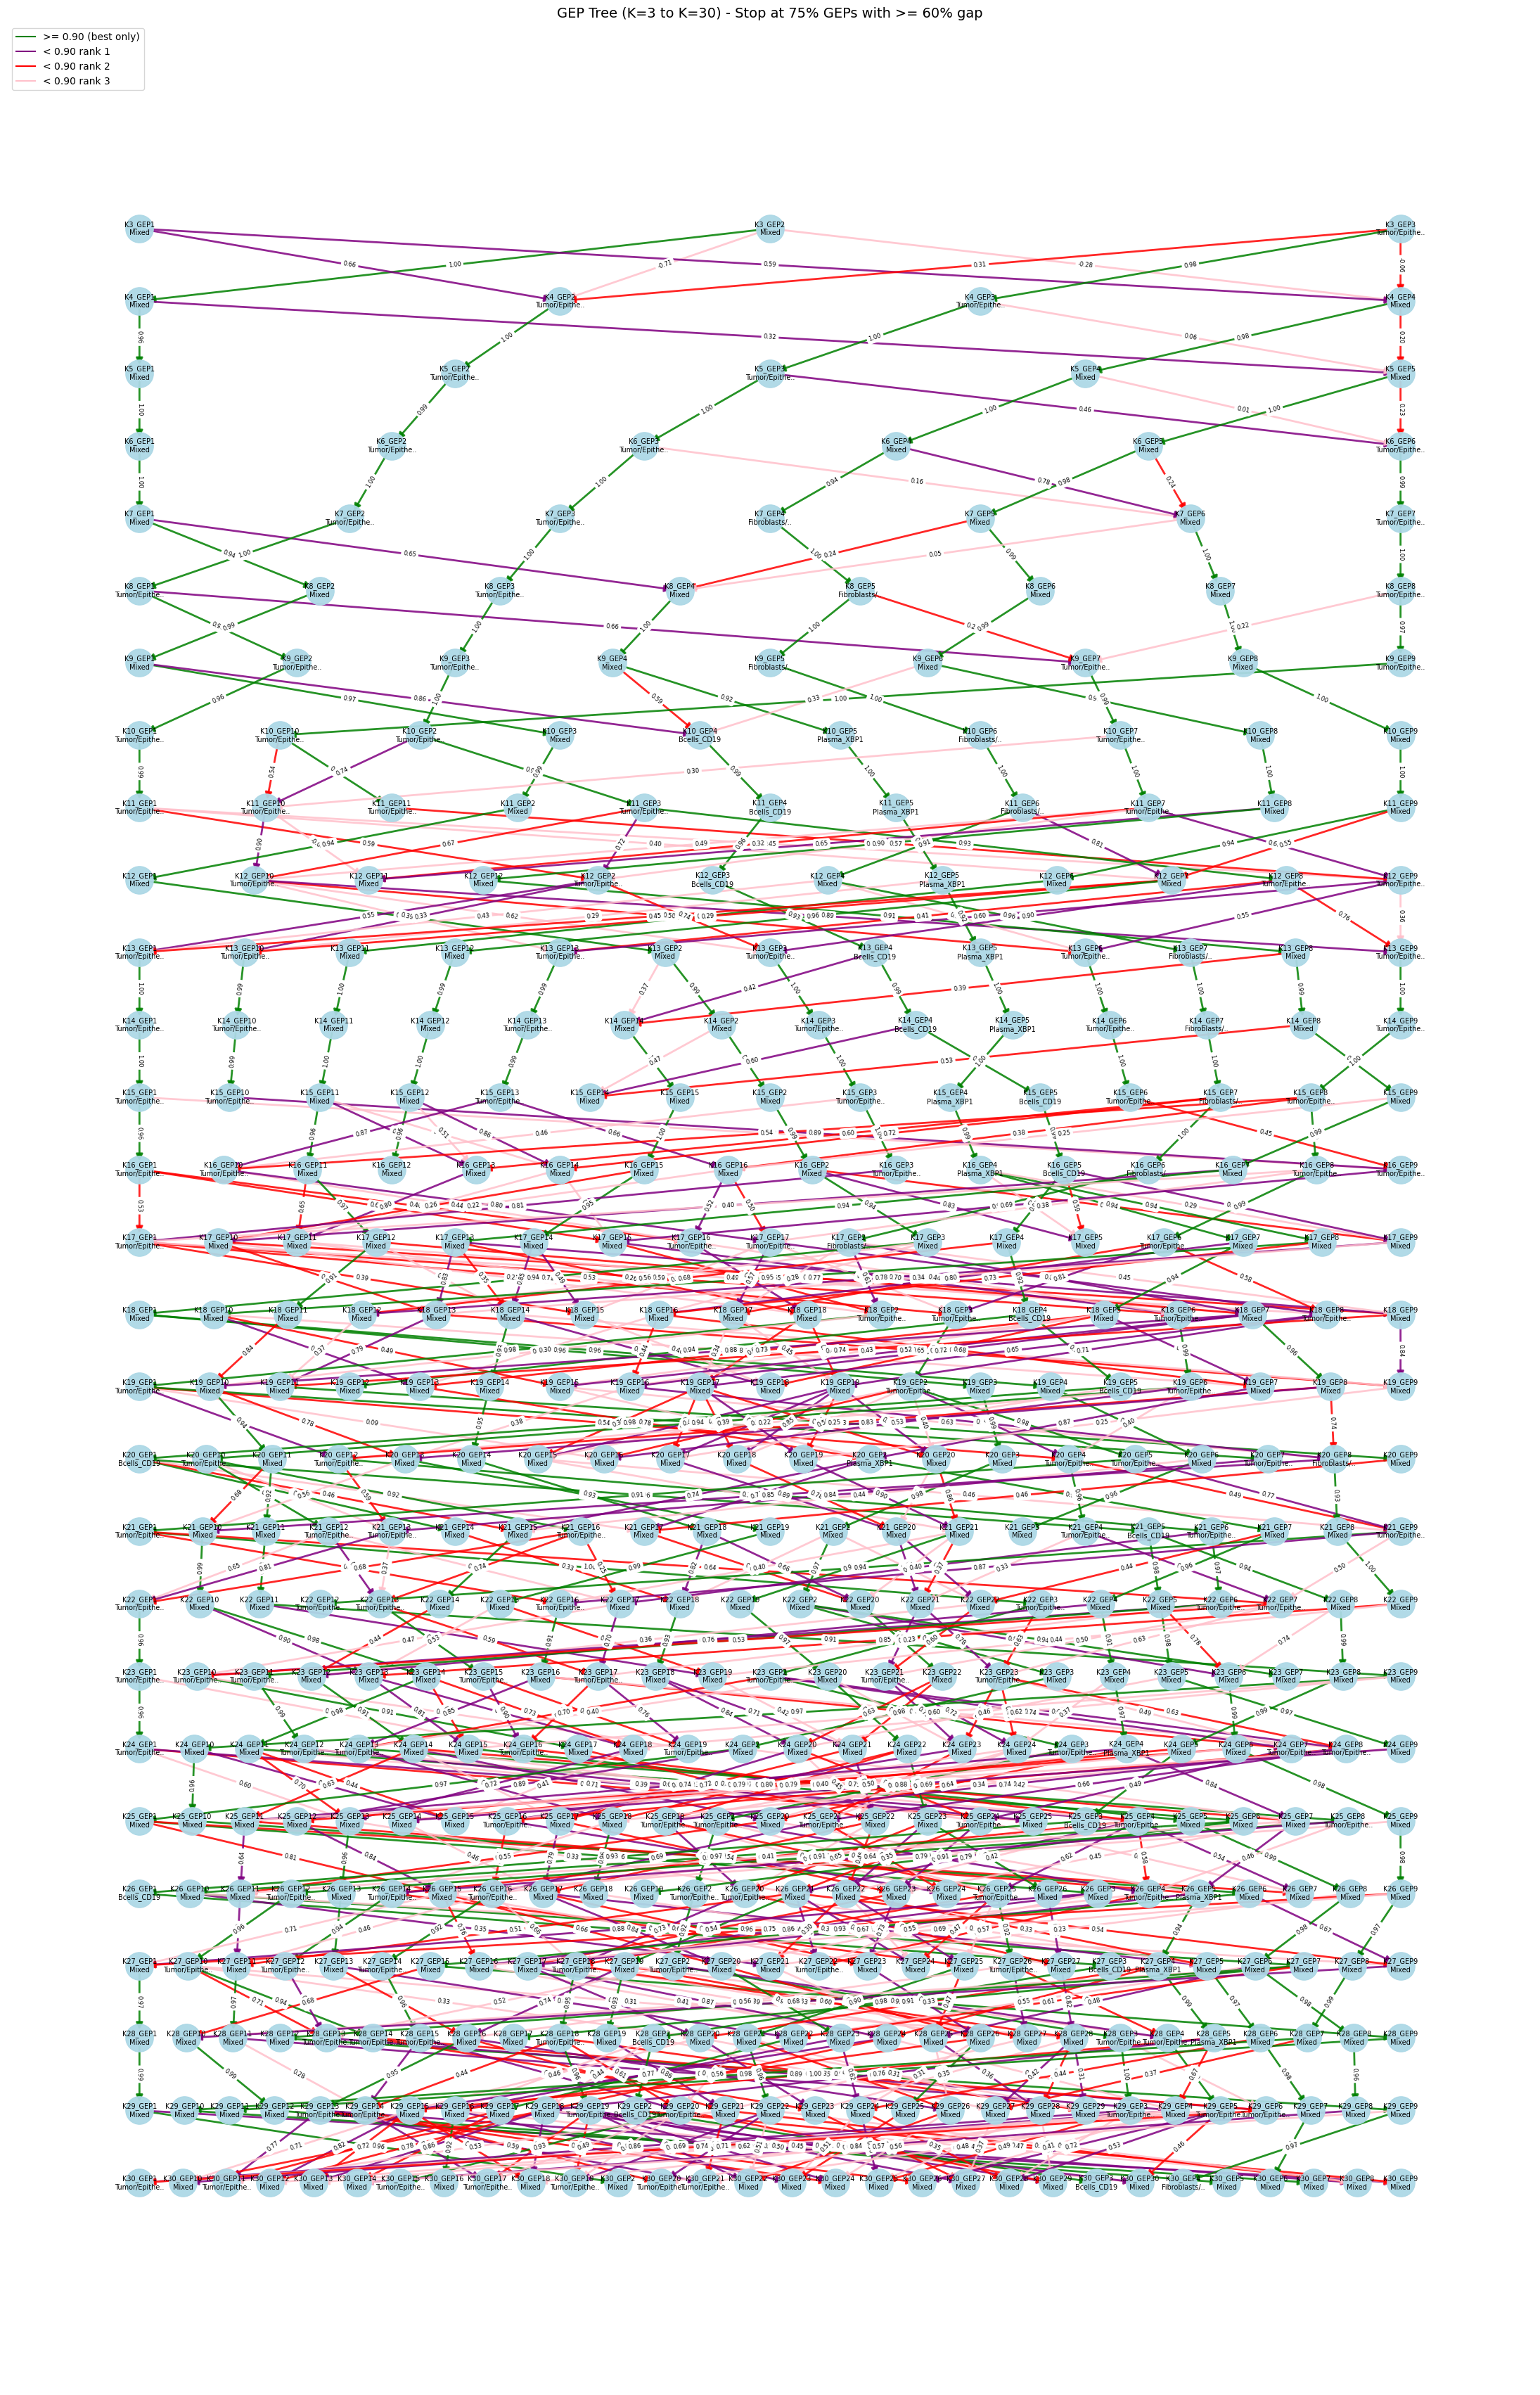

In [19]:
def plot_tree_with_celltypes(
    edges_df: pd.DataFrame, 
    gep_to_celltype: dict,
    gep_to_top1: dict,
    title: str, 
    figsize=(22, 40),
    label_mode: str = "top1"
):
    """Plot GEP tree with cell type annotations. Mixed GEPs shown in footnotes."""
    
    if edges_df is None or len(edges_df) == 0:
        print("No edges to plot.")
        return

    G = nx.DiGraph()
    for _, e in edges_df.iterrows():
        G.add_node(e["parent_id"], level=int(e["parent_k"]))
        G.add_node(e["child_id"],  level=int(e["child_k"]))
        G.add_edge(e["parent_id"], e["child_id"],
                   similarity=float(e["similarity"]), color=e["color"], rank=int(e["rank"]))

    levels = {}
    for n, d in G.nodes(data=True):
        levels.setdefault(d["level"], []).append(n)
    for k in levels:
        levels[k] = sorted(levels[k])

    pos = {}
    for li, k in enumerate(sorted(levels.keys())):
        nodes = levels[k]
        xs = [0.5] if len(nodes) == 1 else np.linspace(0.05, 0.95, len(nodes))
        for x, n in zip(xs, nodes):
            pos[n] = (float(x), float(-li))

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title(title, fontsize=14)

    nx.draw_networkx_nodes(G, pos, node_size=800, alpha=0.95, node_color='lightblue')
    
    labels = {}
    mixed_geps = []
    
    for node in G.nodes():
        top1 = gep_to_top1.get(node, "")
        
        if label_mode == "top1":
            if top1.startswith("Mixed:"):
                labels[node] = f"{node}\nMixed"
                full_annotation = gep_to_celltype.get(node, "")
                mixed_geps.append(f"{node}: {full_annotation}")
            else:
                top1_short = top1[:12] + ".." if len(top1) > 14 else top1
                labels[node] = f"{node}\n{top1_short}"
        elif label_mode == "full":
            if top1.startswith("Mixed:"):
                labels[node] = f"{node}\nMixed"
                full_annotation = gep_to_celltype.get(node, "")
                mixed_geps.append(f"{node}: {full_annotation}")
            else:
                labels[node] = f"{node}\n{gep_to_celltype.get(node, '')}"
        else:
            labels[node] = node
    
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    edgelist = list(G.edges())
    edge_colors = [G.edges[u, v]["color"] for u, v in edgelist]
    nx.draw_networkx_edges(G, pos, edgelist=edgelist, edge_color=edge_colors,
                           arrows=True, arrowstyle="-|>", arrowsize=14, width=2.0, alpha=0.85)
    
    edge_labels = {(u, v): f'{G.edges[u, v]["similarity"]:.2f}' for u, v in edgelist}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

    handles = [
        mlines.Line2D([], [], color="green",  label=f">= {HI_THRESH:.2f} (best only)"),
        mlines.Line2D([], [], color="purple", label=f"< {HI_THRESH:.2f} rank 1"),
        mlines.Line2D([], [], color="red",    label=f"< {HI_THRESH:.2f} rank 2"),
        mlines.Line2D([], [], color="pink",   label=f"< {HI_THRESH:.2f} rank 3"),
    ]
    ax.legend(handles=handles, loc="upper left")
    ax.axis("off")
    
    if mixed_geps:
        print("\n" + "="*70)
        print("Mixed GEPs:")
        print("="*70)
        for gep in mixed_geps:
            print(f"  {gep}")
        print("="*70 + "\n")
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15 if mixed_geps else 0.05)
    plt.show()


plot_tree_with_celltypes(
    edges_df, gep_to_celltype, gep_to_top1,
    title=f"GEP Tree (K={k_chain[0]} to K={k_chain[-1]}) - Stop at {MIN_DIFFERENTIATED_FRACTION*100:.0f}% GEPs with >= {MIN_CELLTYPE_GAP*100:.0f}% gap",
    label_mode="top1"
)

### 7. Summary and export

In [17]:
print("="*70)
print("SUMMARY: Cell Type Composition per GEP")
print(f"Dynamic K_MAX = {optimal_k_max}")
print(f"Stopped when {MIN_DIFFERENTIATED_FRACTION*100:.0f}% of GEPs had >= {MIN_CELLTYPE_GAP*100:.0f}% gap")
print("="*70)

for k in sorted(gep_annotations['K'].unique()):
    k_data = gep_annotations[gep_annotations['K'] == k]
    print(f"\nK={k}:")
    for _, row in k_data.iterrows():
        gap_str = f"[gap: {row['celltype_gap']*100:.0f}%]"
        print(f"  {row['program_id']}: {row['top_celltypes']} {gap_str}")

print("\n" + "="*70)
print("Most frequent TOP-1 cell types across all GEPs:")
print("="*70)
print(gep_annotations['top1_celltype'].value_counts().head(10))

SUMMARY: Cell Type Composition per GEP
Dynamic K_MAX = 30
Stopped when 75% of GEPs had >= 60% gap

K=3:
  K3_GEP1: Mixed: Tumor/Epithelials/Fibroblasts/Stromal/Endothelials (100%), Tumor/Epithelials (63%), Fibroblasts/Stromal (30%), Endothelials (6%) [gap: 33%]
  K3_GEP2: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (51%), Bcells_CD19 (23%), CD4+Tcells (14%), CD8+Tcells (14%) [gap: 9%]
  K3_GEP3: Tumor/Epithelials (100%), Endothelials (0%), Fibroblasts/Stromal (0%) [gap: 100%]

K=4:
  K4_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tcells (52%), Bcells_CD19 (24%), CD4+Tcells (14%), CD8+Tcells (14%) [gap: 9%]
  K4_GEP2: Tumor/Epithelials (98%), Fibroblasts/Stromal (1%), Endothelials (0%) [gap: 97%]
  K4_GEP3: Tumor/Epithelials (100%), Fibroblasts/Stromal (0%), Endothelials (0%) [gap: 99%]
  K4_GEP4: Mixed: Fibroblasts/Stromal/Endothelials/Tumor/Epithelials (97%), Fibroblasts/Stromal (73%), Endothelials (18%), Tumor/Epithelials (6%) [gap: 55%]

K=5:
  K5_GEP1: Mixed: Bcells_CD19/CD4+Tcells/CD8+Tc

In [18]:
# Create output directory if needed
Path(OUT_EDGES_CSV).parent.mkdir(parents=True, exist_ok=True)

edges_df.to_csv(OUT_EDGES_CSV, index=False)
print(f"Saved edges to: {OUT_EDGES_CSV}")

gep_annotations_export = gep_annotations.drop(columns=['top_celltypes_list'])
gep_annotations_export.to_csv(OUT_CELLTYPE_CSV, index=False)
print(f"Saved cell type annotations to: {OUT_CELLTYPE_CSV}")

print(f"\n" + "="*70)
print(f"DONE! Tree built from K={k_chain[0]} to K={optimal_k_max}")
print(f"Stopping criterion:")
print(f"  MIN_CELLTYPE_GAP = {MIN_CELLTYPE_GAP*100:.0f}%")
print(f"  MIN_DIFFERENTIATED_FRACTION = {MIN_DIFFERENTIATED_FRACTION*100:.0f}%")
print("="*70)

Saved edges to: dynamic_hierarch_tree_results/gep_tree_edges_dynamic.csv
Saved cell type annotations to: dynamic_hierarch_tree_results/gep_celltype_annotations_dynamic.csv

DONE! Tree built from K=3 to K=30
Stopping criterion:
  MIN_CELLTYPE_GAP = 60%
  MIN_DIFFERENTIATED_FRACTION = 75%
